In [2]:
import pandas as pd      
import numpy as np

df = pd.read_csv('elantra.csv')
df.head()

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
0,1,2010,7690,9.7,153,213.377,217.466
1,1,2011,9659,9.1,259,229.353,221.082
2,1,2012,10900,8.2,354,244.178,227.666
3,1,2013,12174,7.9,230,242.560,231.321
4,1,2014,15326,6.6,232,247.575,234.933


In [48]:
df.sort_values(by = ['Year', 'Month'], inplace = True)
df.reset_index(inplace = True, drop = True)

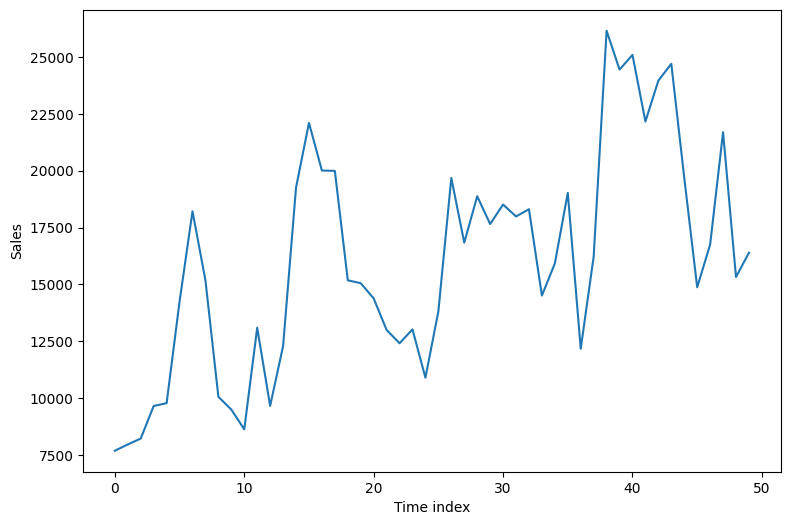

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.plot(df['ElantraSales'].values)
plt.xlabel('Time index')
plt.ylabel('Sales')
# function to show the plot
plt.show()


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Month            50 non-null     int64  
 1   Year             50 non-null     int64  
 2   ElantraSales     50 non-null     int64  
 3   Unemployment     50 non-null     float64
 4   Queries          50 non-null     int64  
 5   CPI_energy       50 non-null     float64
 6   CPI_all          50 non-null     float64
 7   Normalized_Data  50 non-null     int64  
dtypes: float64(3), int64(5)
memory usage: 3.2 KB


In [76]:
numeric_feats = df.columns.drop(['Year', 'Month', 'ElantraSales'])
numeric_feats

Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all', 'Normalized_Data'], dtype='object')

In [124]:
df_train = df[df['Year'] < 2013]
df_test = df[df['Year'] >= 2013]

y_train = df_train['ElantraSales'].values
y_test = df_test['ElantraSales'].values

In [151]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df_train[numeric_feats])

X_train = scaler.transform(df_train[numeric_feats])
X_test = scaler.transform(df_test[numeric_feats])

In [152]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [154]:
def relative_error(y_true, y_pred):
    errors = np.abs(y_pred - y_true).astype(float) / y_true
    return np.mean(errors)*100

y_pred_test = model.predict(X_test)
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred_test)))
print('Relative Error: ', relative_error(y_test, y_pred_test))

RMSE:  4599.649026981198
Relative Error:  19.510050706780667


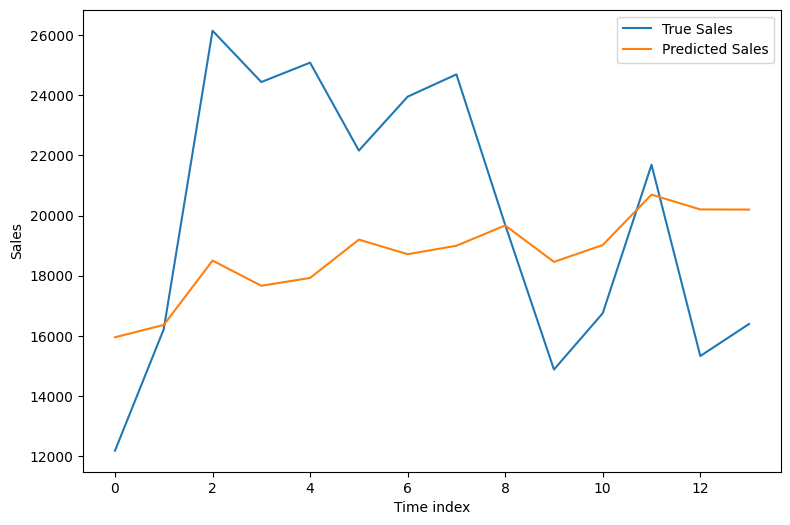

In [155]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.plot(y_test, label='True Sales')
plt.plot(y_pred_test, label='Predicted Sales')
plt.xlabel('Time index')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [156]:
month_onehot_train = pd.get_dummies(df_train['Month'])
month_onehot_train.head()

,1,2,3,4,5,6,7,8,9,10,11,12
0,True,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False


In [157]:
X_onehot_train = np.hstack([X_train, month_onehot_train])
X_train[0]
X_onehot_test = np.hstack([X_test, pd.get_dummies(df_test['Month'])])
# Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all', 'Normalized_Data'])

In [158]:
model.fit(X_onehot_train, y_train)
y_pred_test_onehot = model.predict(X_onehot_test)
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred_test_onehot)))
print('Relative Error: ', relative_error(y_test, y_pred_test_onehot))
print('Accuracy : ', 100 - relative_error(y_test, y_pred_test_onehot))

RMSE:  2891.5836586123664
Relative Error:  9.772010535270605
Accuracy :  90.22798946472939


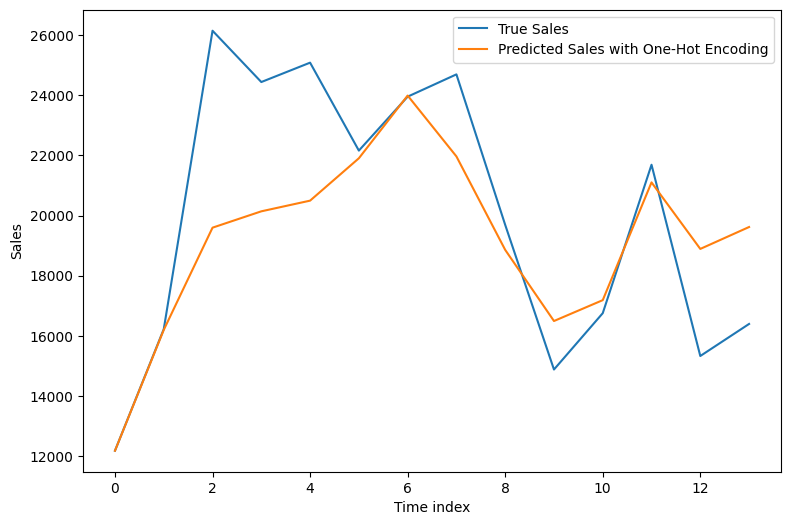

In [159]:
plt.figure(figsize=(9,6))
plt.plot(y_test, label='True Sales')
plt.plot(y_pred_test_onehot, label='Predicted Sales with One-Hot Encoding')
plt.xlabel('Time index')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [190]:
X_train_extra = np.hstack([X_train, df_train['Month'].values.reshape(-1,1)])
X_test_extra = np.hstack([X_test, (df_test['Month'].values.reshape(-1,1))])
# X_train_extra
# Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all', 'Normalized_Data'])

In [191]:
model.fit(X_train_extra, y_train)
y_pred_test_extra = model.predict(X_test_extra)
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred_test_extra)))
print('Relative Error: ', relative_error(y_test, y_pred_test_extra))
print('Accuracy : ', 100 - relative_error(y_test, y_pred_test_extra))

RMSE:  4565.419893980074
Relative Error:  20.338579009608722
Accuracy :  79.66142099039128


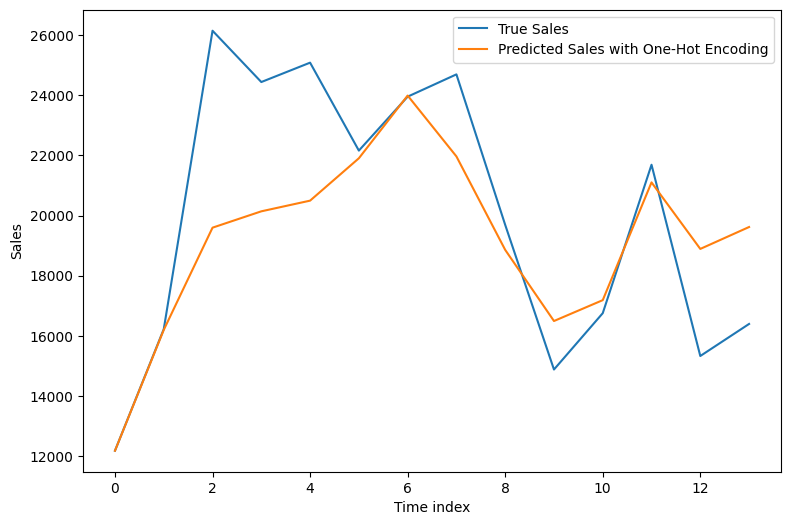

In [192]:
plt.figure(figsize=(9,6))
plt.plot(y_test, label='True Sales')
plt.plot(y_pred_test_onehot, label='Predicted Sales with One-Hot Encoding')
plt.xlabel('Time index')
plt.ylabel('Sales')
plt.legend()
plt.show()